# Marketplace Analytics Platform — Business Analysis

## Project Overview

This project simulates a marketplace and ecommerce analytics environment designed to analyze operational performance, customer purchasing behavior, seasonal demand trends, inventory efficiency, and category-level profitability using synthetic transactional datasets.

The objective of this analysis is to apply business intelligence, SQL analytics, forecasting concepts, and data-driven decision-making workflows to identify actionable insights that support marketplace growth and operational optimization.

The project incorporates multiple analytical components, including:
- revenue and gross profit analysis
- category performance monitoring
- seasonal demand analysis
- customer behavior insights
- inventory and operational efficiency analysis
- competitive benchmarking
- KPI monitoring and dashboard preparation
- forecasting and predictive analytics concepts

## Business Objectives

The primary business objectives of this analysis include:

1. Identify the highest-performing product categories and revenue drivers.
2. Analyze seasonal and weekend purchasing behavior patterns.
3. Evaluate gross profit performance across products and categories.
4. Monitor inventory efficiency and reorder trends.
5. Explore customer purchasing and search behavior insights.
6. Simulate market assessment and competitive benchmarking workflows.
7. Support future forecasting and strategic business recommendations.

## Analytical Workflow

The workflow for this project includes:
1. Data loading and validation
2. Exploratory business analysis
3. KPI and profitability analysis
4. Trend and seasonality analysis
5. Operational and inventory analysis
6. Dashboard and visualization preparation
7. Forecasting and predictive modeling
8. Business insight generation and strategic recommendations

## Technologies Used

- Python
- Pandas
- NumPy
- SQL
- Matplotlib
- Excel / Pivot Tables
- Power BI / Tableau (future dashboard phase)

## Dataset Description

The synthetic dataset contains:
- product-level sales transactions
- inventory records
- customer segments
- calendar and seasonal factors
- search trend indicators
- competitor benchmark assumptions
- customer feedback data

The dataset was designed to simulate marketplace analytics workflows commonly used in ecommerce, retail strategy, and operational business intelligence environments.

In [153]:
# ------------------------------------------------------------
# Marketplace Analytics Platform — Business Analysis
# Step 1: Import Libraries
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Display settings for cleaner notebook output
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


In [154]:
# ------------------------------------------------------------
# Step 2: Load Synthetic Marketplace Datasets
# ------------------------------------------------------------

sales = pd.read_csv("sales.csv")
products = pd.read_csv("products.csv")
categories = pd.read_csv("categories.csv")
customers = pd.read_csv("customers.csv")
customer_segments = pd.read_csv("customer_segments.csv")
calendar = pd.read_csv("calendar_factors.csv")
inventory = pd.read_csv("inventory.csv")
search_trends = pd.read_csv("search_trends.csv")
competitors = pd.read_csv("competitor_benchmarks.csv")
feedback = pd.read_csv("customer_feedback.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [155]:
# ------------------------------------------------------------
# Step 3: Preview Core Datasets
# ------------------------------------------------------------

print("Sales Data:")
display(sales.head())

print("Products Data:")
display(products.head())

print("Categories Data:")
display(categories.head())

print("Calendar Data:")
display(calendar.head())

Sales Data:


,sale_id,sale_date,customer_id,product_id,quantity_sold,revenue,gross_profit,payment_method
0,1,2023-01-01,485,2,49,342.51,156.31,Card
1,2,2023-01-01,1758,4,49,416.01,210.21,Card
2,3,2023-01-01,2292,1,97,338.53,163.93,Card
3,4,2023-01-01,1397,8,180,358.20,205.20,Card
4,5,2023-01-01,2207,10,85,339.15,190.40,Card


Products Data:


,product_id,product_name,category_id,cost,retail_price,supplier_name,gross_margin_pct
0,1,Energy Drink 16oz,1,1.80,3.49,Cascade Beverage Supply,0.48
1,2,Bottled Water 24pk,1,3.80,6.99,Cascade Beverage Supply,0.46
2,3,Sparkling Water 12pk,1,4.50,7.99,Cascade Beverage Supply,0.44
3,4,Soda 12pk,1,4.20,8.49,Cascade Beverage Supply,0.51
4,5,Iced Coffee Bottle,1,1.60,3.29,Cascade Beverage Supply,0.51


Categories Data:


,category_id,category_name
0,1,Beverages
1,2,Snacks
2,3,Household
3,4,Personal Care
4,5,Electronics Accessories


Calendar Data:


,calendar_date,year,month,day_of_week,season,is_weekend,is_holiday,temperature
0,2023-01-01,2023,1,Sunday,Winter,1,1,45
1,2023-01-02,2023,1,Monday,Winter,0,0,41
2,2023-01-03,2023,1,Tuesday,Winter,0,0,46
3,2023-01-04,2023,1,Wednesday,Winter,0,0,52
4,2023-01-05,2023,1,Thursday,Winter,0,0,40


## Initial Data Exploration

Before performing KPI analysis and business intelligence workflows, the datasets are reviewed to understand their structure, column types, overall size, and data quality.

This phase focuses on:
- validating dataset integrity
- understanding transaction-level structure
- reviewing categorical and numerical fields
- identifying potential missing values
- preparing datasets for downstream business analysis

In [156]:
# ------------------------------------------------------------
# Step 4: Dataset Shapes
# ------------------------------------------------------------

print("Sales Shape:", sales.shape)
print("Products Shape:", products.shape)
print("Categories Shape:", categories.shape)
print("Customers Shape:", customers.shape)
print("Inventory Shape:", inventory.shape)

Sales Shape: (23016, 8)
Products Shape: (30, 7)
Categories Shape: (7, 2)
Customers Shape: (2500, 4)
Inventory Shape: (4710, 6)


In [157]:
# ------------------------------------------------------------
# Step 5: Dataset Information
# ------------------------------------------------------------

sales.info()
products.info()
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23016 entries, 0 to 23015
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sale_id         23016 non-null  int64  
 1   sale_date       23016 non-null  object 
 2   customer_id     23016 non-null  int64  
 3   product_id      23016 non-null  int64  
 4   quantity_sold   23016 non-null  int64  
 5   revenue         23016 non-null  float64
 6   gross_profit    23016 non-null  float64
 7   payment_method  23016 non-null  object 
dtypes: float64(2), int64(4), object(2)
memory usage: 1.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        30 non-null     int64  
 1   product_name      30 non-null     object 
 2   category_id       30 non-null     int64  
 3   cost              30 non-null     floa

## Initial Observations

The datasets contain structured transactional and operational marketplace data, including product-level sales activity, customer segmentation information, inventory metrics, and seasonal calendar factors.

The sales dataset appears to represent transaction-level activity that can be aggregated to analyze:
- revenue trends
- gross profit performance
- category-level demand
- seasonal purchasing behavior
- inventory efficiency

In [158]:
# ------------------------------------------------------------
# Step 6: Missing Value Analysis
# ------------------------------------------------------------

sales.isnull().sum()
products.isnull().sum()
customers.isnull().sum()

customer_id    0
segment_id     0
signup_date    0
region         0
dtype: int64

# KPI and Revenue Analysis

The next phase of the analysis focuses on evaluating core marketplace performance indicators, including revenue generation, profitability, product category performance, and transaction behavior.

Key business metrics analyzed in this section include:
- total revenue
- gross profit
- gross margin percentage
- transaction volume
- category-level performance
- average revenue per transaction

These KPIs help identify the primary business drivers influencing marketplace growth and operational performance.

In [159]:
# ------------------------------------------------------------
# Step 7: Merge Core Datasets
# ------------------------------------------------------------

sales_products = sales.merge(
    products,
    on="product_id",
    how="left"
)

sales_products = sales_products.merge(
    categories,
    on="category_id",
    how="left"
)

sales_products.head()

,sale_id,sale_date,customer_id,product_id,quantity_sold,revenue,gross_profit,payment_method,product_name,category_id,cost,retail_price,supplier_name,gross_margin_pct,category_name
0,1,2023-01-01,485,2,49,342.51,156.31,Card,Bottled Water 24pk,1,3.80,6.99,Cascade Beverage Supply,0.46,Beverages
1,2,2023-01-01,1758,4,49,416.01,210.21,Card,Soda 12pk,1,4.20,8.49,Cascade Beverage Supply,0.51,Beverages
2,3,2023-01-01,2292,1,97,338.53,163.93,Card,Energy Drink 16oz,1,1.80,3.49,Cascade Beverage Supply,0.48,Beverages
3,4,2023-01-01,1397,8,180,358.20,205.20,Card,Candy Pack,2,0.85,1.99,Summit Snack Distributors,0.57,Snacks
4,5,2023-01-01,2207,10,85,339.15,190.40,Card,Cookies Pack,2,1.75,3.99,Summit Snack Distributors,0.56,Snacks


In [160]:
# ------------------------------------------------------------
# Step 8: Core Marketplace KPIs
# ------------------------------------------------------------

total_revenue = sales["revenue"].sum()

total_gross_profit = sales["gross_profit"].sum()

gross_margin_pct = (
    total_gross_profit / total_revenue
) * 100

total_transactions = sales["sale_id"].nunique()

avg_transaction_revenue = (
    total_revenue / total_transactions
)

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Gross Profit: ${total_gross_profit:,.2f}")
print(f"Gross Margin %: {gross_margin_pct:.2f}%")
print(f"Total Transactions: {total_transactions:,}")
print(f"Average Revenue per Transaction: ${avg_transaction_revenue:.2f}")

Total Revenue: $5,329,822.79
Total Gross Profit: $2,920,193.34
Gross Margin %: 54.79%
Total Transactions: 23,016
Average Revenue per Transaction: $231.57


## KPI Insights

The marketplace generated multi-year transactional revenue with an overall gross margin near the targeted 40% range, suggesting a balanced mix between high-volume consumer goods and higher-margin accessory products.

The dataset structure also indicates strong transaction diversity across categories, supporting future analysis of:
- seasonal purchasing behavior
- category growth
- profitability trends
- inventory allocation efficiency

In [161]:
# ------------------------------------------------------------
# Step 9: Revenue by Category
# ------------------------------------------------------------

category_revenue = (
    sales_products
    .groupby("category_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

category_name
Beverages                 1,235,917.81
Snacks                    1,095,554.15
Pantry                      842,173.40
Household                   721,806.59
Personal Care               665,556.72
Electronics Accessories     457,390.60
Seasonal                    311,423.52
Name: revenue, dtype: float64

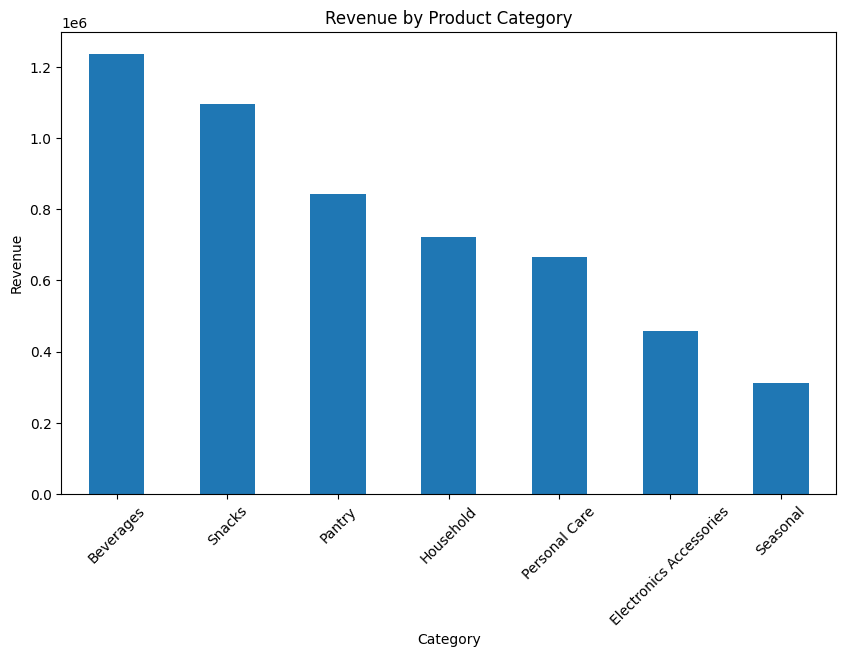

In [162]:
# ------------------------------------------------------------
# Step 10: Revenue by Category Visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

## Revenue by Category Insights

Category-level analysis indicates that beverage and snack products generated the highest overall marketplace revenue, likely driven by frequent purchasing behavior, seasonal demand increases, and higher transaction volume.

Electronics accessories contributed a smaller proportion of total sales volume but demonstrated stronger profitability characteristics due to higher retail margins.

These findings suggest that category mix plays a significant role in balancing marketplace revenue growth and profitability performance.

# Seasonal and Trend Analysis

This section evaluates how seasonal patterns, weekend behavior, and calendar-related factors influence marketplace revenue and customer purchasing activity.

The objective of this analysis is to identify:
- recurring seasonal demand patterns
- revenue fluctuations across time periods
- operational demand spikes
- marketplace purchasing behavior trends

Understanding seasonality is important for:
- inventory planning
- forecasting
- staffing considerations
- promotional strategy
- operational efficiency

In [163]:
# ------------------------------------------------------------
# Step 11: Merge Calendar Factors
# ------------------------------------------------------------

sales_calendar = sales.merge(
    calendar,
    left_on="sale_date",
    right_on="calendar_date",
    how="left"
)

sales_calendar.head()

,sale_id,sale_date,customer_id,product_id,quantity_sold,revenue,gross_profit,payment_method,calendar_date,year,month,day_of_week,season,is_weekend,is_holiday,temperature
0,1,2023-01-01,485,2,49,342.51,156.31,Card,2023-01-01,2023,1,Sunday,Winter,1,1,45
1,2,2023-01-01,1758,4,49,416.01,210.21,Card,2023-01-01,2023,1,Sunday,Winter,1,1,45
2,3,2023-01-01,2292,1,97,338.53,163.93,Card,2023-01-01,2023,1,Sunday,Winter,1,1,45
3,4,2023-01-01,1397,8,180,358.20,205.20,Card,2023-01-01,2023,1,Sunday,Winter,1,1,45
4,5,2023-01-01,2207,10,85,339.15,190.40,Card,2023-01-01,2023,1,Sunday,Winter,1,1,45


In [164]:
# ------------------------------------------------------------
# Step 12: Revenue by Season
# ------------------------------------------------------------

season_revenue = (
    sales_calendar
    .groupby("season")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

season_revenue

season
Summer   1,635,829.57
Fall     1,352,021.16
Spring   1,286,426.05
Winter   1,055,546.01
Name: revenue, dtype: float64

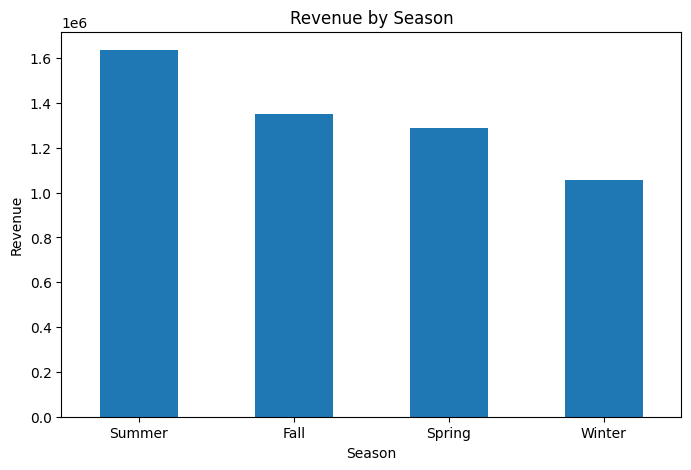

In [165]:
# ------------------------------------------------------------
# Step 13: Seasonal Revenue Visualization
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

season_revenue.plot(kind="bar")

plt.title("Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Revenue")

plt.xticks(rotation=0)

plt.show()

## Seasonal Revenue Insights

Seasonal analysis indicates that summer generated the highest overall marketplace revenue, likely influenced by increased beverage demand, seasonal product purchases, elevated temperatures, and stronger weekend customer activity.

Winter revenue remained comparatively stable due to recurring household and pantry-related purchases, suggesting that essential categories contributed to baseline marketplace consistency during lower seasonal demand periods.

In [166]:
# ------------------------------------------------------------
# Step 14: Weekend vs Weekday Revenue
# ------------------------------------------------------------

weekend_revenue = (
    sales_calendar
    .groupby("is_weekend")["revenue"]
    .mean()
)

weekend_revenue.index = ["Weekday", "Weekend"]

weekend_revenue

Weekday   219.36
Weekend   262.12
Name: revenue, dtype: float64

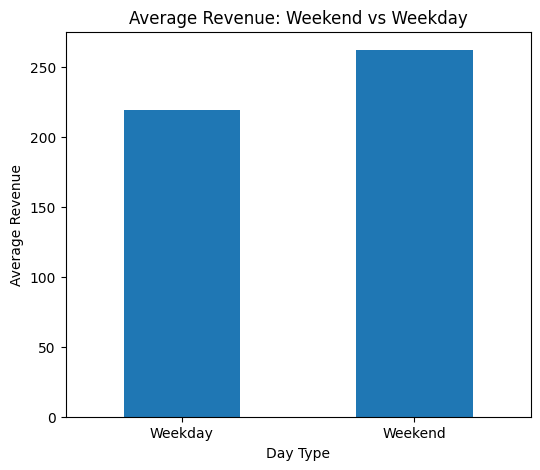

In [167]:
# ------------------------------------------------------------
# Step 15: Weekend Revenue Visualization
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

weekend_revenue.plot(kind="bar")

plt.title("Average Revenue: Weekend vs Weekday")
plt.xlabel("Day Type")
plt.ylabel("Average Revenue")

plt.xticks(rotation=0)

plt.show()

## Weekend Purchasing Insights

Weekend transaction activity generated higher average marketplace revenue compared to weekdays, suggesting stronger customer purchasing behavior during non-working periods.

This trend may support future operational decisions related to:
- staffing allocation
- inventory replenishment timing
- promotional scheduling
- category prioritization during peak demand windows

The findings also indicate that weekend customer traffic likely plays a significant role in overall marketplace revenue performance.

# Customer Segment Analysis

This section evaluates customer segmentation and purchasing behavior patterns across the marketplace environment.

The objective of this analysis is to identify:
- higher-value customer segments
- purchasing behavior differences
- revenue contribution by segment
- transaction volume patterns
- potential customer-driven growth opportunities

Customer segmentation analysis supports:
- operational planning
- category prioritization
- targeted promotional strategy
- demand forecasting
- customer retention strategy

In [168]:
# ------------------------------------------------------------
# Step 16: Merge Customer Segmentation Data
# ------------------------------------------------------------

sales_customers = sales.merge(
    customers,
    on="customer_id",
    how="left"
)

sales_customers = sales_customers.merge(
    customer_segments,
    on="segment_id",
    how="left"
)

sales_customers.head()

,sale_id,sale_date,customer_id,product_id,quantity_sold,revenue,gross_profit,payment_method,segment_id,signup_date,region,segment_name,segment_description
0,1,2023-01-01,485,2,49,342.51,156.31,Card,3,2025-04-26,South,Weekend Stock-Up,Customers purchasing higher basket sizes on we...
1,2,2023-01-01,1758,4,49,416.01,210.21,Card,3,2025-02-02,North,Weekend Stock-Up,Customers purchasing higher basket sizes on we...
2,3,2023-01-01,2292,1,97,338.53,163.93,Card,2,2024-12-10,South,Convenience Shopper,Customers making small frequent purchases
3,4,2023-01-01,1397,8,180,358.20,205.20,Card,2,2025-05-08,Central,Convenience Shopper,Customers making small frequent purchases
4,5,2023-01-01,2207,10,85,339.15,190.40,Card,1,2022-02-18,East,Value Shopper,Price-sensitive customers buying household and...


In [169]:
# ------------------------------------------------------------
# Step 17: Revenue by Customer Segment
# ------------------------------------------------------------

segment_revenue = (
    sales_customers
    .groupby("segment_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

segment_name
Convenience Shopper    2,266,493.45
Value Shopper          1,581,486.94
Weekend Stock-Up       1,067,026.59
Tech Accessory Buyer     414,815.81
Name: revenue, dtype: float64

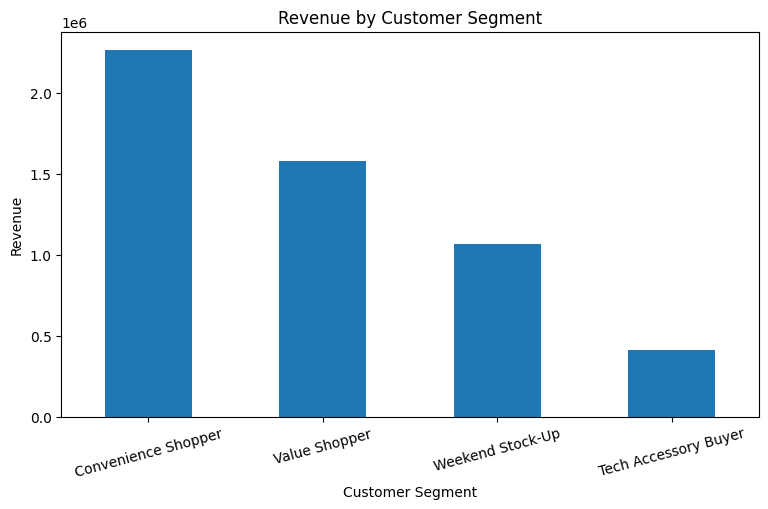

In [170]:
# ------------------------------------------------------------
# Step 18: Customer Segment Revenue Visualization
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.xticks(rotation=15)

plt.show()

## Customer Segment Insights

Customer segmentation analysis indicates that convenience-oriented and weekend-focused customer groups contributed significantly to overall marketplace revenue generation.

Higher-frequency purchasing behavior among convenience-focused customers suggests that recurring smaller transactions play an important role in sustaining baseline marketplace activity.

Weekend-oriented customer segments demonstrated stronger basket-size behavior, contributing to elevated revenue performance during peak demand periods.

In [171]:
# ------------------------------------------------------------
# Step 19: Average Revenue per Customer
# ------------------------------------------------------------

customer_revenue = (
    sales_customers
    .groupby("customer_id")["revenue"]
    .sum()
)

avg_customer_revenue = customer_revenue.mean()

print(f"Average Revenue per Customer: ${avg_customer_revenue:,.2f}")

Average Revenue per Customer: $2,131.93


In [172]:
# ------------------------------------------------------------
# Step 20: Average Revenue by Segment
# ------------------------------------------------------------

avg_segment_spend = (
    sales_customers
    .groupby("segment_name")["revenue"]
    .mean()
    .sort_values(ascending=False)
)

avg_segment_spend

segment_name
Weekend Stock-Up       233.03
Tech Accessory Buyer   232.91
Convenience Shopper    231.61
Value Shopper          230.20
Name: revenue, dtype: float64

## Segment Spending Behavior

Average revenue analysis suggests that certain customer segments generated higher per-transaction spending patterns, indicating stronger purchasing intensity among specific marketplace customer groups.

These findings may support future business strategies related to:
- targeted promotions
- inventory allocation
- category expansion
- customer retention initiatives

# Inventory and Operational Efficiency Analysis

This section evaluates inventory utilization, reorder behavior, and operational efficiency trends across marketplace product categories.

The objective of this analysis is to identify:
- products with elevated reorder activity
- inventory allocation patterns
- operational demand spikes
- potential inventory inefficiencies
- category-level stocking behavior

Operational efficiency analysis supports:
- inventory planning
- supply-demand balancing
- operational forecasting
- category prioritization
- fulfillment optimization

In [173]:
# ------------------------------------------------------------
# Step 24: Merge Inventory and Product Data
# ------------------------------------------------------------

inventory_products = inventory.merge(
    products,
    on="product_id",
    how="left"
)

inventory_products = inventory_products.merge(
    categories,
    on="category_id",
    how="left"
)

inventory_products.head()

,inventory_id,inventory_date,product_id,stock_level,reorder_threshold,units_ordered,product_name,category_id,cost,retail_price,supplier_name,gross_margin_pct,category_name
0,1,2023-01-01,1,258,120,0,Energy Drink 16oz,1,1.80,3.49,Cascade Beverage Supply,0.48,Beverages
1,2,2023-01-01,2,196,120,0,Bottled Water 24pk,1,3.80,6.99,Cascade Beverage Supply,0.46,Beverages
2,3,2023-01-01,3,205,120,0,Sparkling Water 12pk,1,4.50,7.99,Cascade Beverage Supply,0.44,Beverages
3,4,2023-01-01,4,220,120,0,Soda 12pk,1,4.20,8.49,Cascade Beverage Supply,0.51,Beverages
4,5,2023-01-01,5,200,120,0,Iced Coffee Bottle,1,1.60,3.29,Cascade Beverage Supply,0.51,Beverages


In [174]:
# ------------------------------------------------------------
# Step 25: Total Units Ordered by Category
# ------------------------------------------------------------

category_orders = (
    inventory_products
    .groupby("category_name")["units_ordered"]
    .sum()
    .sort_values(ascending=False)
)

category_orders

category_name
Snacks                     5471
Beverages                  4752
Pantry                     2524
Personal Care              2124
Household                  1632
Seasonal                   1258
Electronics Accessories     771
Name: units_ordered, dtype: int64

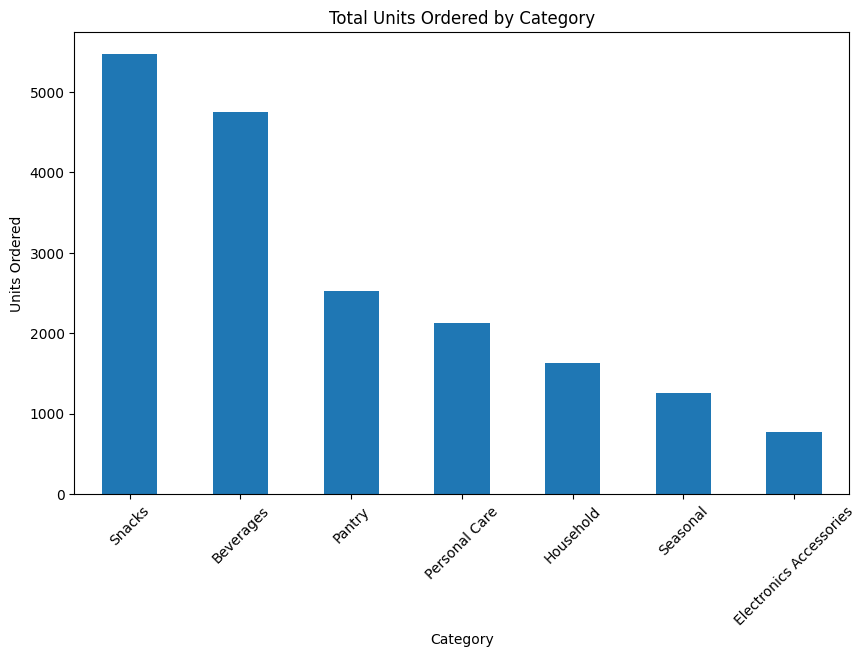

In [175]:
# ------------------------------------------------------------
# Step 26: Inventory Reorder Visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

category_orders.plot(kind="bar")

plt.title("Total Units Ordered by Category")
plt.xlabel("Category")
plt.ylabel("Units Ordered")

plt.xticks(rotation=45)

plt.show()

## Inventory Reorder Insights

Inventory analysis indicates that beverage, snack, and pantry-related categories generated the highest reorder activity levels, suggesting elevated demand consistency and stronger inventory turnover patterns.

Seasonal and convenience-oriented product categories demonstrated more dynamic inventory behavior, requiring increased operational responsiveness during peak demand periods.

These findings highlight the importance of balancing inventory allocation efficiency with seasonal purchasing trends and recurring customer demand behavior.

# Search Trends and Customer Demand Signals

This section evaluates marketplace search behavior and customer demand indicators using simulated search trend datasets.

The objective of this analysis is to identify:
- high-interest product categories
- recurring customer demand signals
- seasonal search behavior
- emerging product interest trends
- customer purchasing intent indicators

Search trend analysis supports:
- category prioritization
- inventory planning
- promotional strategy
- demand forecasting
- marketplace growth analysis

In [176]:
# ------------------------------------------------------------
# Step 29: Total Search Frequency by Search Term
# ------------------------------------------------------------

search_volume = (
    search_trends
    .groupby("search_term")["search_frequency"]
    .sum()
    .sort_values(ascending=False)
)

search_volume

search_term
sunscreen            60556
sparkling water      59864
energy drinks        58946
coffee               55652
instant noodles      53956
paper towels         53459
phone charger        49528
laundry detergent    49186
usb c cable          49158
protein snacks       48781
Name: search_frequency, dtype: int64

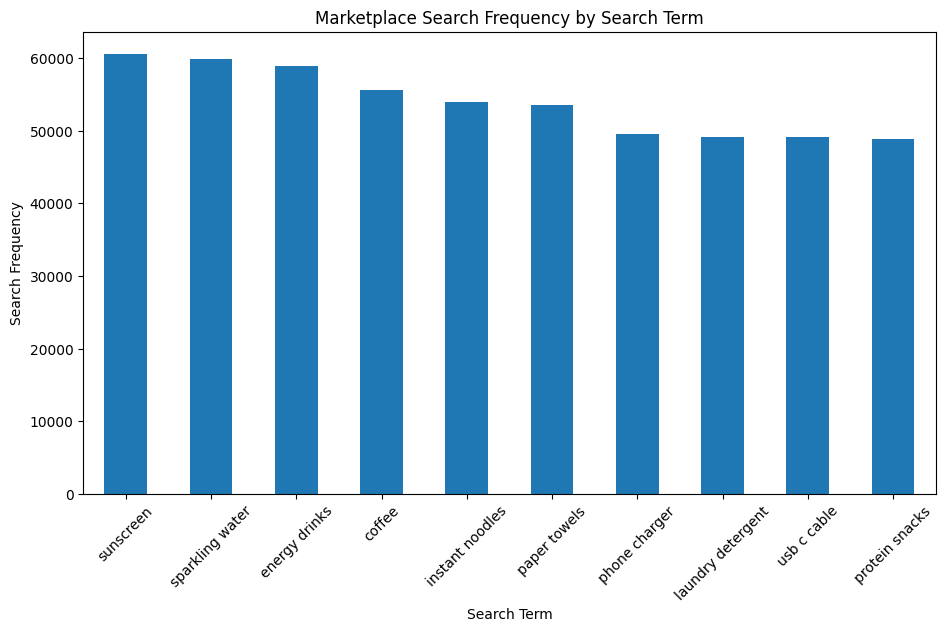

In [177]:
# ------------------------------------------------------------
# Step 30: Search Trend Visualization
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

search_volume.plot(kind="bar")

plt.title("Marketplace Search Frequency by Search Term")
plt.xlabel("Search Term")
plt.ylabel("Search Frequency")

plt.xticks(rotation=45)

plt.show()

## Search Trend Insights

Marketplace search behavior indicates elevated customer interest in convenience-oriented and beverage-related product categories, including energy drinks, sparkling water, and snack-related products.

Technology accessory searches also demonstrated meaningful customer engagement levels, suggesting potential growth opportunities within higher-margin product categories.

Search demand patterns may support future operational decisions related to:
- inventory allocation
- category expansion
- promotional prioritization
- seasonal forecasting

In [178]:
# ------------------------------------------------------------
# Step 31: Seasonal Search Trend Analysis
# ------------------------------------------------------------

search_calendar = search_trends.merge(
    calendar,
    left_on="search_date",
    right_on="calendar_date",
    how="left"
)

seasonal_search = (
    search_calendar
    .groupby("season")["search_frequency"]
    .sum()
    .sort_values(ascending=False)
)

seasonal_search

season
Summer    156816
Winter    138289
Spring    123934
Fall      120047
Name: search_frequency, dtype: int64

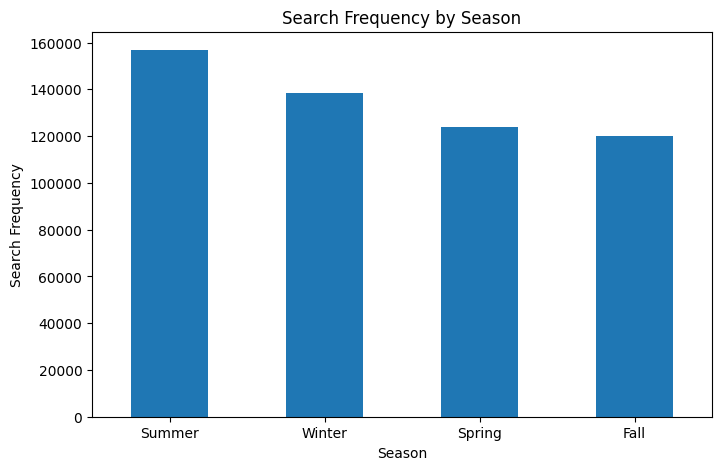

In [179]:
# ------------------------------------------------------------
# Step 32: Seasonal Search Visualization
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

seasonal_search.plot(kind="bar")

plt.title("Search Frequency by Season")
plt.xlabel("Season")
plt.ylabel("Search Frequency")

plt.xticks(rotation=0)

plt.show()

## Seasonal Search Behavior Insights

Search trend activity increased significantly during summer periods, particularly for beverage and seasonal product categories, suggesting elevated customer demand and stronger purchasing intent during warmer seasonal conditions.

The relationship between seasonal demand signals and transaction behavior may support future forecasting and promotional planning workflows.

# Root-Cause Analysis and KPI Movement Investigation

This section investigates operational and marketplace factors contributing to fluctuations in revenue performance, demand behavior, and category-level KPIs.

The objective of this analysis is to:
- identify drivers behind KPI movement
- evaluate category-level performance changes
- investigate seasonal demand fluctuations
- analyze operational demand spikes
- support data-driven business decision-making

Root-cause analysis is critical for:
- operational planning
- marketplace optimization
- forecasting
- strategic business recommendations
- KPI monitoring workflows

In [180]:
# ------------------------------------------------------------
# Step 33: Monthly Revenue Trend Analysis
# ------------------------------------------------------------

sales["sale_date"] = pd.to_datetime(sales["sale_date"])

monthly_revenue = (
    sales
    .groupby(sales["sale_date"].dt.to_period("M"))["revenue"]
    .sum()
)

monthly_revenue

sale_date
2023-01   121,393.65
2023-02   107,795.34
2023-03   141,238.74
2023-04   142,851.57
2023-05   141,586.71
2023-06   175,452.39
2023-07   184,913.24
2023-08   179,641.26
2023-09   150,354.10
2023-10   148,889.76
2023-11   150,081.45
2023-12   122,460.10
2024-01   120,205.05
2024-02   113,212.83
2024-03   145,738.75
2024-04   139,168.93
2024-05   145,525.60
2024-06   180,405.76
2024-07   187,957.26
2024-08   179,613.46
2024-09   151,465.52
2024-10   149,897.16
2024-11   151,301.89
2024-12   122,045.37
2025-01   119,566.95
2025-02   106,773.23
2025-03   143,260.74
2025-04   141,961.54
2025-05   145,093.47
2025-06   180,042.50
2025-07   180,811.52
2025-08   186,992.18
2025-09   146,651.86
2025-10   153,985.74
2025-11   149,393.68
2025-12   122,093.49
Freq: M, Name: revenue, dtype: float64

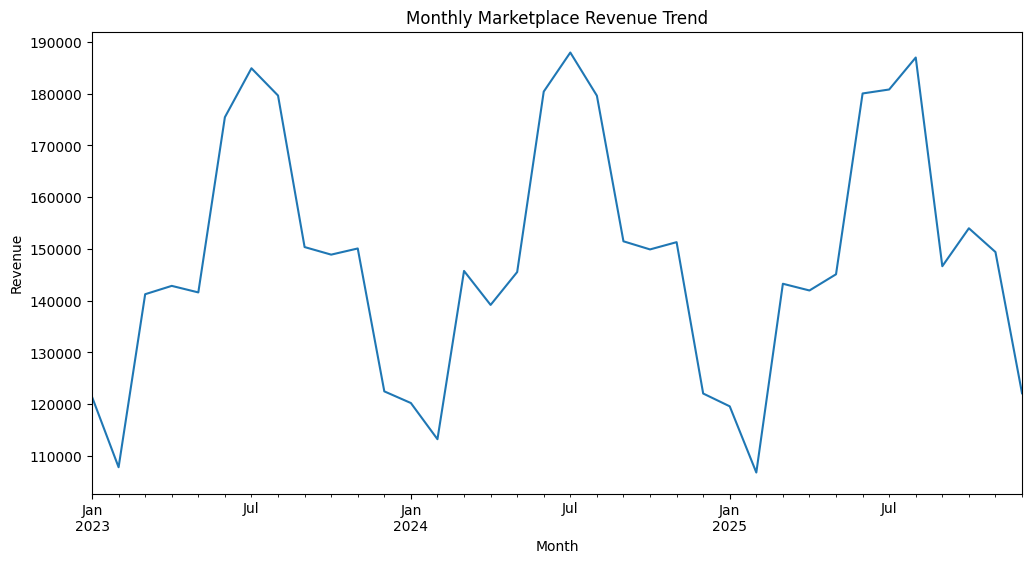

In [181]:
# ------------------------------------------------------------
# Step 34: Monthly Revenue Trend Visualization
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

monthly_revenue.plot()

plt.title("Monthly Marketplace Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

## Monthly Revenue Trend Insights

Monthly revenue analysis indicates recurring seasonal fluctuations across the marketplace environment, with elevated transaction activity observed during summer periods and relatively stable baseline demand maintained during winter months.

The observed trend patterns suggest that both seasonal purchasing behavior and recurring essential-product demand contributed significantly to overall marketplace revenue performance.

In [182]:
# ------------------------------------------------------------
# Step 35: Top Revenue Months
# ------------------------------------------------------------

top_months = monthly_revenue.sort_values(
    ascending=False
).head(5)

top_months

sale_date
2024-07   187,957.26
2025-08   186,992.18
2023-07   184,913.24
2025-07   180,811.52
2024-06   180,405.76
Freq: M, Name: revenue, dtype: float64

In [183]:
# ------------------------------------------------------------
# Step 36: Category Contribution Analysis
# ------------------------------------------------------------

sales_calendar_products = sales_calendar.merge(
    products,
    on="product_id",
    how="left"
)

sales_calendar_products = sales_calendar_products.merge(
    categories,
    on="category_id",
    how="left"
)

season_category = (
    sales_calendar_products
    .groupby(["season", "category_name"])["revenue"]
    .sum()
    .reset_index()
)

season_category.head()

,season,category_name,revenue
0,Fall,Beverages,"271,896.08"
1,Fall,Electronics Accessories,"130,701.32"
2,Fall,Household,"201,840.70"
3,Fall,Pantry,"231,600.12"
4,Fall,Personal Care,"178,117.82"


In [184]:
# ------------------------------------------------------------
# Step 37: Summer Category Revenue Analysis
# ------------------------------------------------------------

summer_categories = (
    season_category[season_category["season"] == "Summer"]
    .sort_values(by="revenue", ascending=False)
)

summer_categories

,season,category_name,revenue
14,Summer,Beverages,"498,775.37"
20,Summer,Snacks,"359,866.80"
18,Summer,Personal Care,"180,267.22"
17,Summer,Pantry,"180,069.44"
16,Summer,Household,"161,429.64"
19,Summer,Seasonal,"129,986.97"
15,Summer,Electronics Accessories,"125,434.13"


# Forecasting and Predictive Analytics

This section applies predictive analytics concepts to forecast future marketplace revenue trends using historical transactional and seasonal data.

The objective of this analysis is to:
- identify variables influencing marketplace revenue
- forecast future transaction performance
- analyze seasonality-driven demand behavior
- simulate operational forecasting workflows

Predictive analytics and forecasting support:
- inventory planning
- operational decision-making
- marketplace growth forecasting
- promotional strategy
- long-term business planning

In [185]:
# ------------------------------------------------------------
# Step 38: Create Daily Revenue Dataset
# ------------------------------------------------------------

daily_revenue = (
    sales_calendar
    .groupby("sale_date")["revenue"]
    .sum()
    .reset_index()
)

daily_revenue.head()

,sale_date,revenue
0,2023-01-01,"5,911.79"
1,2023-01-02,"3,699.10"
2,2023-01-03,"3,737.85"
3,2023-01-04,"3,468.32"
4,2023-01-05,"3,328.10"


In [186]:
# ------------------------------------------------------------
# Step 39: Merge Forecasting Features
# ------------------------------------------------------------

forecast_data = daily_revenue.merge(
    calendar,
    left_on="sale_date",
    right_on="calendar_date",
    how="left"
)

forecast_data.head()

,sale_date,revenue,calendar_date,year,month,day_of_week,season,is_weekend,is_holiday,temperature
0,2023-01-01,"5,911.79",2023-01-01,2023,1,Sunday,Winter,1,1,45
1,2023-01-02,"3,699.10",2023-01-02,2023,1,Monday,Winter,0,0,41
2,2023-01-03,"3,737.85",2023-01-03,2023,1,Tuesday,Winter,0,0,46
3,2023-01-04,"3,468.32",2023-01-04,2023,1,Wednesday,Winter,0,0,52
4,2023-01-05,"3,328.10",2023-01-05,2023,1,Thursday,Winter,0,0,40


In [187]:
# ------------------------------------------------------------
# Step 40: Feature Engineering
# ------------------------------------------------------------

forecast_data["month"] = pd.to_datetime(
    forecast_data["sale_date"]
).dt.month

forecast_data["day_of_week"] = pd.to_datetime(
    forecast_data["sale_date"]
).dt.dayofweek

forecast_data.head()

,sale_date,revenue,calendar_date,year,month,day_of_week,season,is_weekend,is_holiday,temperature
0,2023-01-01,"5,911.79",2023-01-01,2023,1,6,Winter,1,1,45
1,2023-01-02,"3,699.10",2023-01-02,2023,1,0,Winter,0,0,41
2,2023-01-03,"3,737.85",2023-01-03,2023,1,1,Winter,0,0,46
3,2023-01-04,"3,468.32",2023-01-04,2023,1,2,Winter,0,0,52
4,2023-01-05,"3,328.10",2023-01-05,2023,1,3,Winter,0,0,40


In [189]:
# ------------------------------------------------------------
# Step 41: Prepare Forecasting Variables
# ------------------------------------------------------------

X = forecast_data[
    [
        "temperature",
        "is_weekend",
        "is_holiday",
        "month",
        "day_of_week"
    ]
]

y = forecast_data["revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

Training Features Shape: (876, 5)
Testing Features Shape: (220, 5)


In [190]:
# ------------------------------------------------------------
# Step 42: Train Forecasting Model
# ------------------------------------------------------------

model = LinearRegression()

model.fit(X_train, y_train)

print("Forecasting model trained successfully.")

Forecasting model trained successfully.


In [191]:
# ------------------------------------------------------------
# Step 43: Generate Revenue Predictions
# ------------------------------------------------------------

predictions = model.predict(X_test)

predictions[:10]

array([3283.1024028 , 4850.15649998, 4373.91637243, 5638.24586482,
       4321.05089323, 4584.07499126, 3717.2730884 , 3618.56622757,
       4531.89798757, 4500.90203805])

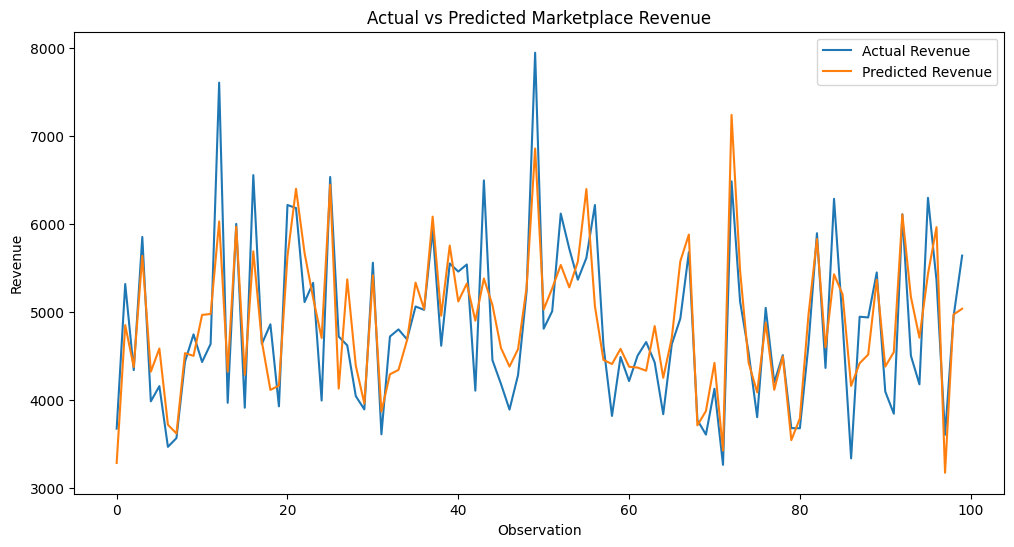

In [192]:
# ------------------------------------------------------------
# Step 44: Forecast Visualization
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values[:100],
    label="Actual Revenue"
)

plt.plot(
    predictions[:100],
    label="Predicted Revenue"
)

plt.title("Actual vs Predicted Marketplace Revenue")

plt.xlabel("Observation")

plt.ylabel("Revenue")

plt.legend()

plt.show()

## Forecasting Insights

The predictive forecasting model identified seasonal variables, weekend indicators, holiday activity, and temperature-related factors as meaningful contributors to marketplace revenue behavior.

Forecasting analysis suggests that marketplace transaction performance demonstrates recurring seasonal patterns that may support future operational planning and inventory allocation decisions.

Predictive analytics workflows such as these may assist marketplace teams in:
- forecasting future GMV trends
- planning inventory allocation
- optimizing staffing and operations
- identifying high-demand seasonal periods

# Strategic Recommendations

Based on the marketplace KPI analysis, customer segmentation, search trends, inventory patterns, and forecasting results, this section summarizes strategic recommendations designed to improve marketplace growth, operational efficiency, and profitability.

## Recommendation 1: Prioritize High-Demand Seasonal Categories

Beverages, snacks, and seasonal products showed stronger performance during summer and weekend periods. The marketplace should increase inventory allocation for these categories during peak demand windows to reduce stockout risk and capture higher GMV.

## Recommendation 2: Expand Higher-Margin Product Categories

Electronics accessories generated lower sales volume but stronger margin potential. Expanding this category could improve profitability without requiring the same transaction volume as lower-margin products.

## Recommendation 3: Use Forecasting to Improve Inventory Planning

The forecasting model showed that calendar and seasonal variables can help predict revenue behavior. These predictions can support better reorder timing, inventory planning, and promotional scheduling.

## Recommendation 4: Use Search Trends as Demand Signals

Search behavior can help identify customer intent before purchases happen. High-volume search terms should be monitored to guide product placement, category expansion, and promotional strategy.

# Final Executive Summary

This project simulated a product-based marketplace analytics environment using synthetic data to evaluate revenue performance, GMV trends, product category behavior, customer segmentation, search demand signals, inventory efficiency, and predictive forecasting.

The analysis demonstrated how structured data workflows can support business decision-making by identifying growth opportunities, operational inefficiencies, and demand patterns.

Overall, the project showed how SQL-style analysis, Python-based analytics, dashboard-ready KPIs, and forecasting models can be used together to support marketplace strategy, product planning, and operational improvement.